<center><image src="https://drive.google.com/uc?id=1n3G4TdK_u6PQHcLrxB_A0HijNdigXmUH">

<h3 style="text-align: center;"><b>Школа глубокого обучения ФПМИ МФТИ</b></h3>

<h3 style="text-align: center;"><b>Домашнее задание. Сегментация изображений</b></h3>


В этом задании вам предстоит решить задачу сегментации медицинских снимков. Домашнее задание можно разделить на следующие части:

* Построй свой первый бейзлайн! [6]
  * BCE Loss [2]
  * SegNet [2]
  * Train [1]
  * Test [1]
* Мир других лоссов! [2]
  * Dice Loss [1]
  * Focal Loss [1]
  * BONUS: лосс из статьи [5]
* Новая модель! [2]
  * UNet [2]


**Максимальный балл:** 10 баллов.

Также для студентов желающих еще более углубиться в задачу предлагается решить бонусное задание, которое даст дополнительные 5 баллов. BONUS задание необязательное.


# Шаг 1. Загрузка и подготовка данных

1. Для начала мы скачаем датасет: [ADDI project](https://www.fc.up.pt/addi/ph2%20database.html).

<table><tr><td>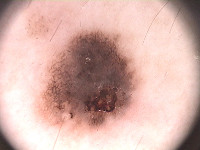</td><td>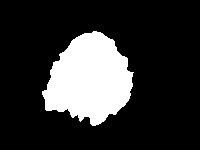</td></tr></table>

2. Разархивируем .rar файл.
3. Обратите внимание, что папка  `PH2 Dataset images` должна лежать там же где и ipynb notebook.

Это фотографии двух типов **поражений кожи:** меланома и родинки.
В данном задании мы не будем заниматься их классификацией, а будем **сегментировать** их.

In [5]:
!gdown 1T_RPkPP0jeWwK8L1UrmBw8V30eD7v6Ql

Downloading...
From (original): https://drive.google.com/uc?id=1T_RPkPP0jeWwK8L1UrmBw8V30eD7v6Ql
From (redirected): https://drive.google.com/uc?id=1T_RPkPP0jeWwK8L1UrmBw8V30eD7v6Ql&confirm=t&uuid=18f205b3-3809-49e3-9b63-37d5ee8c085e
To: /content/PH2Dataset.rar
100% 162M/162M [00:01<00:00, 128MB/s]


In [6]:
get_ipython().system_raw("unrar x PH2Dataset.rar")

Стуктура датасета у нас следующая:

    IMD_002/
        IMD002_Dermoscopic_Image/
            IMD002.bmp
        IMD002_lesion/
            IMD002_lesion.bmp
        IMD002_roi/
            ...
    IMD_003/
        ...
        ...

 Здесь `X.bmp` — изображение, которое нужно сегментировать, `X_lesion.bmp` — результат сегментации.

Для загрузки датасета можно использовать skimage: [`skimage.io.imread()`](https://scikit-image.org/docs/dev/api/skimage.io.html)

In [7]:
images = []
lesions = []
from skimage.io import imread
import os
root = 'PH2Dataset'

for root, dirs, files in os.walk(os.path.join(root, 'PH2 Dataset images')):
    if root.endswith('_Dermoscopic_Image'):
        images.append(imread(os.path.join(root, files[0])))
    if root.endswith('_lesion'):
        lesions.append(imread(os.path.join(root, files[0])))

Изображения имеют разные размеры. Давайте изменим их размер на $256\times256 $ пикселей. Для изменения размера изображений можно использовать [`skimage.transform.resize()`](https://scikit-image.org/docs/dev/api/skimage.transform.html#skimage.transform.resize).
Эта функция также автоматически нормализует изображения в диапазоне $[0,1]$.


In [8]:
from skimage.transform import resize
size = (256, 256)
X = [resize(x, size, mode='constant', anti_aliasing=True,) for x in images]
Y = [resize(y, size, mode='constant', anti_aliasing=False) > 0.5 for y in lesions]

In [9]:
import numpy as np
X = np.array(X, np.float32)
Y = np.array(Y, np.float32)
print(f'Loaded {len(X)} images')

Loaded 200 images


Чтобы убедиться, что все корректно, мы нарисуем несколько изображений

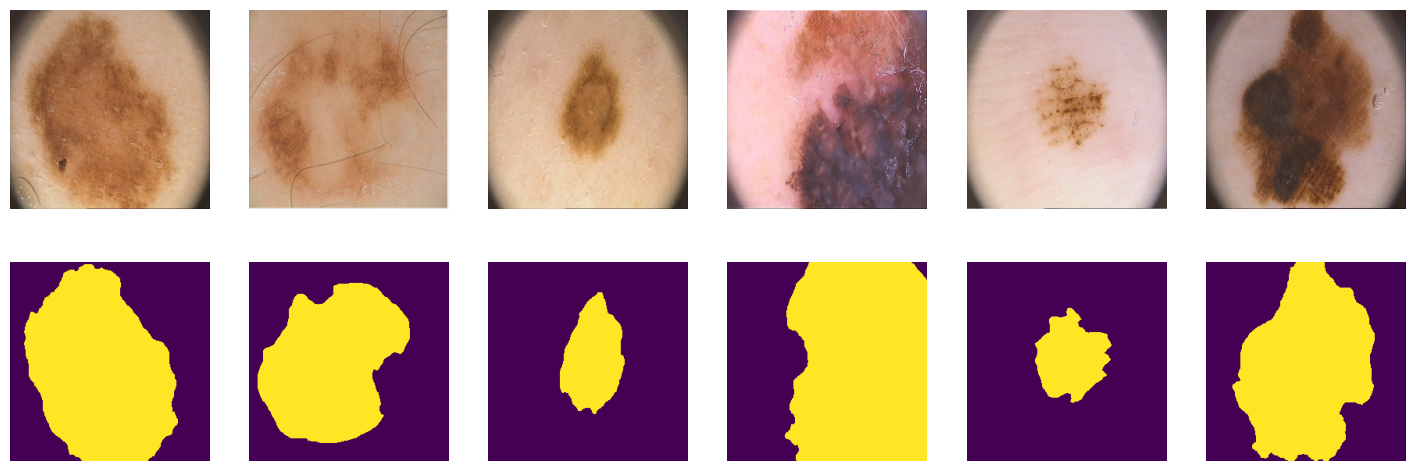

In [10]:
import matplotlib.pyplot as plt
from IPython.display import clear_output

plt.figure(figsize=(18, 6))
for i in range(6):
    plt.subplot(2, 6, i+1)
    plt.axis("off")
    plt.imshow(X[i])

    plt.subplot(2, 6, i+7)
    plt.axis("off")
    plt.imshow(Y[i])
plt.show();

Разделим наши 200 картинок на 100/50/50
 для обучения, валидации и теста соответственно

In [11]:
ix = np.random.choice(len(X), len(X), False)
tr, val, ts = np.split(ix, [100, 150])

In [12]:
print(len(tr), len(val), len(ts))

100 50 50


## PyTorch DataLoader

In [13]:
from torch.utils.data import DataLoader
batch_size = 25
train_dataloader = DataLoader(list(zip(np.rollaxis(X[tr], 3, 1), Y[tr, np.newaxis])),
                     batch_size=batch_size, shuffle=True)
valid_dataloader = DataLoader(list(zip(np.rollaxis(X[val], 3, 1), Y[val, np.newaxis])),
                      batch_size=batch_size, shuffle=False)
test_dataloader = DataLoader(list(zip(np.rollaxis(X[ts], 3, 1), Y[ts, np.newaxis])),
                     batch_size=batch_size, shuffle=False)

In [14]:
import torch
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

cuda


# Шаг 2. Метрика качества модели

## IoU (intersection over union)

В данном разделе предлагается использовать следующую метрику для оценки качества:

$I o U=\frac{\text {target } \cap \text { prediction }}{\text {target } \cup{prediction }}$

Пересечение (A ∩ B) состоит из пикселей, найденных как в маске предсказания, так и в основной маске истины, тогда как объединение (A ∪ B) просто состоит из всех пикселей, найденных либо в маске предсказания, либо в целевой маске.


Что будет являться пересением и объединением в задаче сегментации?

Давайте разберем следующий пример:





<p style="align: center;"><img align=center src="https://drive.google.com/uc?export=view&id=1rBYFgli48AUUN9idiyq8j3J5DboB93yN" width=1000 height=800/></p>

In [17]:
!pip install torchmetrics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 27.5 MB/s eta 0:00:00


In [18]:
from torchmetrics import JaccardIndex

iou_score = JaccardIndex(threshold=0.5, task="binary", average='none').to(device)

# Задания: Построй свой первый бейзлайн!

Итак, загрузка файлов, код датасета и даталоадера написана за вас. Метрика IoU написана за вас! Вам остается написать лосс, модель и функции обучения и теста модели.

* Построй свой первый бейзлайн! [6]
  * BCE Loss [2]
  * SegNet [2]
  * Train [1]
  * Test [1]

## Шаг 3. Loss функция - BCE [2 балла]

Популярным лоссом для бинарной сегментации является *бинарная кросс-энтропия*, которая задается следующим образом:

$$\mathcal L_{BCE}(y, \hat y) = -\sum_i \left[y_i\log\sigma(\hat y_i) + (1-y_i)\log(1-\sigma(\hat y_i))\right] \space [1]$$

где $y$ это  таргет желаемого результата и $\hat y$ является выходом модели. $\sigma$ - это [*логистическая* функция](https://en.wikipedia.org/wiki/Sigmoid_function), который преобразует действительное число $\mathbb R$ в вероятность $[0,1]$.

Однако эта потеря страдает от проблем численной нестабильности. Самое главное, что $\lim_{x\rightarrow0}\log(x)=\infty$ приводит к неустойчивости в процессе оптимизации. Рекомендуется посмотреть следующее [упрощение](https://www.tensorflow.org/api_docs/python/tf/nn/sigmoid_cross_entropy_with_logits). Эта функция эквивалентна первой и не так подвержена численной неустойчивости:

$$\mathcal L_{BCE} = \hat y - y\hat y + \log\left(1+\exp(-\hat y)\right) \space [2]$$

### Вывод численно стабильной формулы BCE лосса [1 балл]



Выведите из формулы [1] формулу [2]:

$$\mathcal L_{BCE}(y, \hat y) = -\sum_i \left[y_i\log\sigma(\hat y_i) + (1-y_i)\log(1-\sigma(\hat y_i))\right] \space [1]$$

$$\mathcal L_{BCE} = \hat y - y\hat y + \log\left(1+\exp(-\hat y)\right) \space [2]$$

Не забываем, что здесь $\hat y_i$ - это логиты сети, не вероятности и не лейблы.

**Ответ:**

Рассмотрим бинарную кросс-энтропию для одного пикселя с истинной меткой $ y \in \{0,1\} $ и логитом $ \hat y \in \mathbb{R} $:

$$
\mathcal{L}_{BCE}(y, \hat y) = - \Big[ y \log \sigma(\hat y) + (1-y) \log(1-\sigma(\hat y)) \Big], \qquad \sigma(x) = \frac{1}{1+e^{-x}}.
$$

Упростим логарифмы:

$$
\sigma(x) = \frac{1}{1+e^{-x}} \;\Longrightarrow\; \log\sigma(x) = -\log(1+e^{-x}),
$$

$$
1-\sigma(x) = \frac{e^{-x}}{1+e^{-x}} \;\Longrightarrow\; \log(1-\sigma(x)) = -x - \log(1+e^{-x}).
$$

Подставим в исходное выражение:

$$
\begin{aligned}
\mathcal{L}_{BCE}(y, \hat y)
&= -y\bigl(-\log(1+e^{-\hat y})\bigr) - (1-y)\bigl(-\hat y - \log(1+e^{-\hat y})\bigr) \\
&= y\log(1+e^{-\hat y}) + (1-y)\hat y + (1-y)\log(1+e^{-\hat y}) \\
&= (y + 1 - y)\log(1+e^{-\hat y}) + \hat y - y\hat y \\
&= \log(1+e^{-\hat y}) + \hat y - y\hat y.
\end{aligned}
$$

Таким образом, для одного элемента численно стабильная форма:

$$
\mathcal{L}_{BCE}(y, \hat y) = \hat y - y\hat y + \log(1+e^{-\hat y}).
$$

Суммируя по всем пикселям \( i \), получаем итоговую стабильную формулу:

$$
\mathcal{L}_{BCE} = \sum_i \Big[ \hat y_i - y_i\hat y_i + \log(1+e^{-\hat y_i}) \Big]
$$

Эта формула использует только логиты \( \hat y \) и не содержит потенциально неустойчивого логарифма от нуля, поэтому является численно стабильной.

### Реализуйте в коде оба варианта лосса [1 балл]

Реализуйте следующие функции:

*   `bce_true()` - честная прямая реализация лосса с формулой $$\mathcal L_{BCE}(y, \hat y) = -\sum_i \left[y_i\log\sigma(\hat y_i) + (1-y_i)\log(1-\sigma(\hat y_i))\right].$$
*   `bce_loss()` - реализация формулы, которую мы вывели $$\mathcal L_{BCE} = \hat y - y\hat y + \log\left(1+\exp(-\hat y)\right).$$

И сравните результаты функций с реализацией Pytorch:
*   `bce_torch()`
*   `bce_torch_with_logits()`

In [19]:
import torch.nn.functional as F
import torch.nn as nn

In [20]:
bce_torch = nn.BCELoss(reduction='sum') # (sigmoid(y_pred), y_real)
bce_torch_with_logits = nn.BCEWithLogitsLoss(reduction='sum')

In [21]:
def bce_loss(y_pred, y_real):
    # Численно стабильная версия BCELoss с логитами (формула [2])
    # y_pred: логиты
    # y_real: целевая маска (0 или 1)
    loss = y_pred - y_real * y_pred + torch.log(1 + torch.exp(-y_pred))
    return loss.sum()

def bce_true(y_pred, y_real):
    # Прямая реализация BCE с сигмоидой (формула [1])
    eps = 1e-8
    preds = torch.sigmoid(y_pred)
    loss = -(y_real * torch.log(preds + eps) + (1 - y_real) * torch.log(1 - preds + eps))
    return loss.sum()

Проверим корректность работы на простом примере

In [22]:
y_pred = torch.randn(3, 2, requires_grad=False)
y_true = torch.rand(3, 2, requires_grad=False)

print(f'BCE loss from scratch bce_loss             = {bce_loss(y_pred, y_true)}')
print(f'BCE loss честно посчитанный                = {bce_true(y_pred, y_true)}')
print(f'BCE loss from torch bce_torch              = {bce_torch(torch.sigmoid(y_pred), y_true)}')
print(f'BCE loss from torch with logits bce_torch  = {bce_torch_with_logits(y_pred, y_true)}')


BCE loss from scratch bce_loss             = 4.064628601074219
BCE loss честно посчитанный                = 4.064628601074219
BCE loss from torch bce_torch              = 4.064628601074219
BCE loss from torch with logits bce_torch  = 4.0646281242370605


Инструкции `assert` в Python — это булевы выражения, которые проверяют, является ли условие истинным (`True`). Внизу в коде мы проверяем функция `bce_loss()` выдает тот же результат, что и функция из Pytorch или нет. Если равенства не будет, что будет означать, что результаты функций не совпадают, а значит вы неправильно реализовали фукнцию `bce_loss()`, `assert` возвратит ошибку.

Функция `numpy.isclose()` используется для сравнения двух чисел с учётом допустимой погрешности. Она особенно полезна при работе с числами с плавающей точкой, где точное сравнение может быть проблематичным из-за ограничений представления таких чисел в компьютере.

Как она работает?

`numpy.isclose(a, b, rtol=1e-05, atol=1e-08) `принимает два числа (`a` и `b`) и сравнивает их, учитывая относительную и абсолютную погрешность. Если разница между двумя числами меньше заданного порога, функция возвращает `True`, иначе — `False`.

Параметры:

    rtol: Относительная погрешность (по умолчанию 1e-05). Используется для определения разницы относительно большего значения.
    atol: Абсолютная погрешность (по умолчанию 1e-08). Определяет минимальную разницу, которую следует учитывать.

Мы будем использовать `assert` и `numpy.isclose()` для проверки корректности нашего кода.

In [23]:
assert np.isclose(bce_loss(y_pred, y_true), bce_torch(torch.sigmoid(y_pred), y_true))
assert np.isclose(bce_loss(y_pred, y_true), bce_torch_with_logits(y_pred, y_true))
assert np.isclose(bce_true(y_pred, y_true), bce_torch(torch.sigmoid(y_pred), y_true))
assert np.isclose(bce_true(y_pred, y_true), bce_torch_with_logits(y_pred, y_true))

Давайте теперь посчитаем на простом примере, но с теми же размерностями, что и в датасете

In [24]:
y_pred = torch.randn((2, 1, 3, 3), requires_grad=False)
y_true = torch.randint(0, 2, (2, 1, 3, 3))

print(f'BCE loss from scratch bce_loss            = {bce_loss(y_pred, y_true)}')
print(f'BCE loss честно посчитанный               = {bce_true(y_pred, y_true)}')
print(f'BCE loss from torch bce_torch             = {bce_torch(torch.sigmoid(y_pred), y_true.to(torch.float))}')
print(f'BCE loss from torch with logits bce_torch = {bce_torch_with_logits(y_pred, y_true.to(torch.float))}')

BCE loss from scratch bce_loss            = 12.47392463684082
BCE loss честно посчитанный               = 12.47392463684082
BCE loss from torch bce_torch             = 12.47392463684082
BCE loss from torch with logits bce_torch = 12.47392463684082


In [25]:
assert np.isclose(bce_loss(y_pred, y_true), bce_torch(torch.sigmoid(y_pred), y_true.to(torch.float)))
assert np.isclose(bce_loss(y_pred, y_true), bce_torch_with_logits(y_pred, y_true.to(torch.float)))
assert np.isclose(bce_true(y_pred, y_true), bce_torch(torch.sigmoid(y_pred), y_true.to(torch.float)))
assert np.isclose(bce_true(y_pred, y_true), bce_torch_with_logits(y_pred, y_true.to(torch.float)))

Давайте посчитаем на реальных логитах и сегментационной маске:

In [26]:
!gdown --folder 1EX0RW1TRQVkLmR1h6miCQqyhYPFyg28M

Retrieving folder contents
Processing file 1--WxvBdpMn_NOmYPf3a4au8MHzfx5baC labels.pt
Processing file 1-0A7_CS_vKiSCkgIDJ4joThCEcFedA3I logits.pt
Retrieving folder contents completed
Building directory structure
Building directory structure completed
Downloading...
From: https://drive.google.com/uc?id=1--WxvBdpMn_NOmYPf3a4au8MHzfx5baC
To: /content/for_asserts/labels.pt
100% 1.18k/1.18k [00:00<00:00, 5.28MB/s]
Downloading...
From: https://drive.google.com/uc?id=1-0A7_CS_vKiSCkgIDJ4joThCEcFedA3I
To: /content/for_asserts/logits.pt
100% 1.18k/1.18k [00:00<00:00, 6.91MB/s]
Download completed


In [27]:
path_to_dummy_samples = '/content/for_asserts'
dummpy_sample = {'logits': torch.load(f'{path_to_dummy_samples}/logits.pt'),
                 'labels': torch.load(f'{path_to_dummy_samples}/labels.pt')}
dummpy_sample['labels'] = dummpy_sample['labels'].to(device)
dummpy_sample['logits'] = dummpy_sample['logits'].to(device)

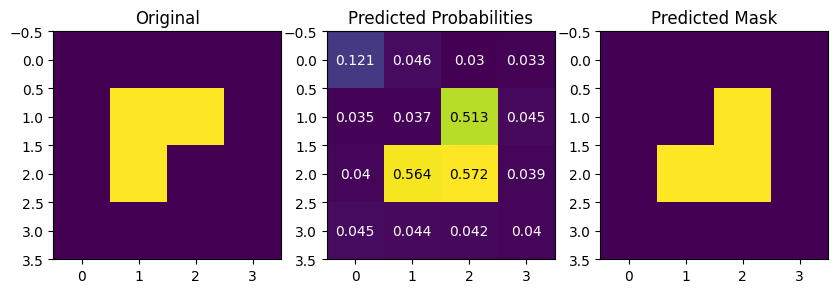

In [28]:
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize= (10,3*10))

ax1.imshow(dummpy_sample['labels'].squeeze(1)[0].cpu())
ax1.set_title("Original")

ax2.imshow(dummpy_sample['logits'].sigmoid().squeeze(1)[0].cpu())
for (j,i),label in np.ndenumerate(dummpy_sample['logits'].sigmoid().squeeze(1)[0].cpu()):
    if label < 0.5:
        color = 'white'
    else:
        color = 'black'
    ax2.text(i,j,round(label,3), color=color, ha='center',va='center')

ax2.set_title("Predicted Probabilities")

ax3.imshow((dummpy_sample['logits'].sigmoid() > 0.5).squeeze(1)[0].cpu())
ax3.set_title("Predicted Mask")
plt.show()

Проверяем на данном примере:

In [29]:
bce_loss_score = bce_loss(dummpy_sample['logits'].cpu(), dummpy_sample['labels'].cpu())
bce_true_score = bce_true(dummpy_sample['logits'].cpu(), dummpy_sample['labels'].cpu())
bce_torch_score = bce_torch(torch.sigmoid(dummpy_sample['logits'].cpu()), dummpy_sample['labels'].cpu().float())
bce_torch_with_logits_score = bce_torch_with_logits(dummpy_sample['logits'].cpu(), dummpy_sample['labels'].cpu().float())
assert np.isclose(bce_loss_score, bce_torch_score)
assert np.isclose(bce_loss_score, bce_torch_with_logits_score)
assert np.isclose(bce_true_score, bce_torch_score)
assert np.isclose(bce_true_score, bce_torch_with_logits_score)

## Шаг 4. Модель SegNet [2 балла]

Ваше задание здесь состоит в том, чтобы реализовать SegNet архитектуру.

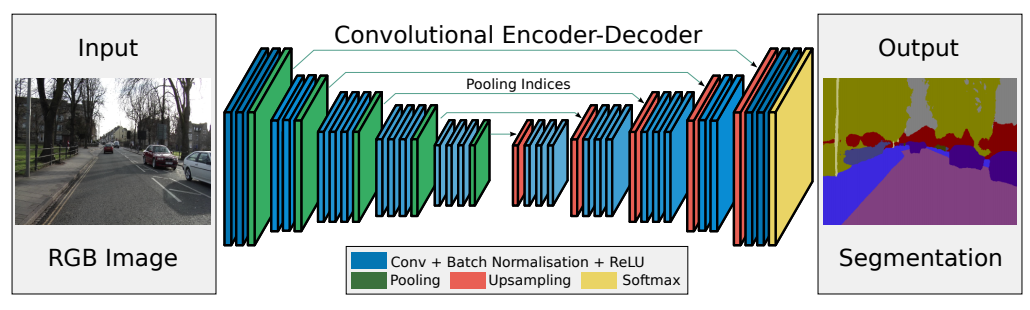

* Badrinarayanan, V., Kendall, A., & Cipolla, R. (2015). [SegNet: A deep convolutional
encoder-decoder architecture for image segmentation](https://arxiv.org/pdf/1511.00561.pdf)

In [30]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import models
import torch.optim as optim
from time import time

from matplotlib import rcParams
rcParams['figure.figsize'] = (15,4)

Внимательно посмотрите из чего состоит модель и для чего выбраны те или иные блоки. Для этого скачаем и изучим feature extractor VGG-16, который лежит в основе SegNet.

In [31]:
model_vgg16 = models.vgg16(weights = models.VGG16_Weights.IMAGENET1K_V1)

Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth


100%|██████████| 528M/528M [00:03<00:00, 181MB/s]


In [32]:
model_vgg16

VGG(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU(inplace=True)
    (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU(inplace=True)
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU(inplace=True)
    (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (15): ReLU(inplace=True)
    (16): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1

Feature extractor VGG-16 состоит из 5 блоков:
- два блока со структурой:
Conv2d -> ReLU -> Conv2d -> ReLU -> MaxPool2d
- три блока со структурой:
Conv2d -> ReLU -> Conv2d -> ReLU -> Conv2d -> ReLU -> MaxPool2d

В первом блоке - на входе три канала (по числу каналов в изображениях), которые конволюционный слой преобразует в 64 канала.

Во втором, третьем и четвертом блоках первый конволюционный слой удваивает количество каналов, а последующие конволюционные слои не меняют количество каналов.

В последнем блоке число каналов от слоя к слою не меняется.

Теперь напишем код одного блока энкодера нашей модели SegNet.  

In [33]:
# Параметрами блока будут:
# - количество каналов на входе
# - количество каналов на выходе
# - глубина блока (2 или 3, по количеству конволюционных слоев)
# - kernel_size и padding
#
class EncoderBlock(nn.Module):
    def __init__(self, in_channels, out_channels, depth, kernel_size = 3, padding = 1):
        super(EncoderBlock, self).__init__() # инициируем экземляр класса, наследующего от nn.Module
        self.layers = nn.ModuleList() # в self.layers будем добавлять слои блока
        # дальше реализуем то, что на картинке выше обозначено Conv + Batch Normalization + ReLU
        self.layers.append(nn.Conv2d(in_channels = in_channels, out_channels = out_channels, kernel_size = kernel_size, padding = padding))
        self.layers.append(nn.BatchNorm2d(out_channels))
        self.layers.append(nn.ReLU(inplace=True))

        # цикл for помогает использовать один код для блоков как с глубиной 2, так и с глубиной 3
        for i in range(depth-1):
            self.layers.append(nn.Conv2d(in_channels = out_channels, out_channels = out_channels, kernel_size = kernel_size, padding = padding))
            self.layers.append(nn.BatchNorm2d(out_channels))
            self.layers.append(nn.ReLU(inplace=True))

        self.maxpooling = nn.MaxPool2d(kernel_size=2, stride=2, return_indices=True) #добавляем MaxPool с индексами для последующего Unpooling

    # Обратите внимание: на вход метод forward() получает карту признаков (х),
    # а возвращает карту признаков и индексы для последующего Unpooling
    def forward(self, x):
        for layer in self.layers:
            x = layer(x)
        x, indices = self.maxpooling(x)
        return x, indices


По аналогии напишите код одного блока декодера.

К карте признаков на входе каждого блока примеяется nn.MaxUnpool2d с индексами из симметричного блока энкодера. Затем повторяется связка Conv + Batch Normalization + ReLU. Количество каналов меняется зеркально блокам энкодера:
- в первом блоке декодера количество каналов не меняется
- во 2-4 блоках декодера количество каналов уменьшается в 2 раза после прохождения последнего конволюционного слоя
- на выходе из последнего блока декодера 1 канал

Обратите внимание, что после последней конволюции последнего блока декодера не применяется батч-нормализация и функция активации.

In [34]:
class DecoderBlock(nn.Module):
    def __init__(self, in_channels, out_channels, depth, kernel_size=3, padding=1, final_block=False):
        super(DecoderBlock, self).__init__()
        self.unpool = nn.MaxUnpool2d(kernel_size=2, stride=2)

        layers = []
        # Первая свёртка (обязательная)
        layers.append(nn.Conv2d(in_channels, out_channels, kernel_size, padding=padding))
        if not final_block:
            layers.append(nn.BatchNorm2d(out_channels))
            layers.append(nn.ReLU(inplace=True))

        # Дополнительные свёртки (глубина > 1)
        for i in range(depth - 1):
            if final_block:
                # В последнем блоке без BN/ReLU
                layers.append(nn.Conv2d(out_channels, out_channels, kernel_size, padding=padding))
            else:
                layers.append(nn.Conv2d(out_channels, out_channels, kernel_size, padding=padding))
                layers.append(nn.BatchNorm2d(out_channels))
                layers.append(nn.ReLU(inplace=True))

        self.layers = nn.Sequential(*layers)

    def forward(self, x, indices):
        x = self.unpool(x, indices)
        x = self.layers(x)
        return x

Соединим блоки энкодера и декодера в модель SegNet:

In [35]:
class SegNet(nn.Module):
    def __init__(self, in_channels=3, out_channels=1, num_features=64):
        super(SegNet, self).__init__()
        # Encoder
        self.encoder0 = EncoderBlock(in_channels, num_features, depth=2)
        self.encoder1 = EncoderBlock(num_features, num_features * 2, depth=2)
        self.encoder2 = EncoderBlock(num_features * 2, num_features * 4, depth=3)
        self.encoder3 = EncoderBlock(num_features * 4, num_features * 8, depth=3)
        self.encoder4 = EncoderBlock(num_features * 8, num_features * 8, depth=3)  # bottleneck

        # Decoder bottleneck
        self.decoder4 = DecoderBlock(num_features * 8, num_features * 8, depth=3, final_block=False)
        # Decoder
        self.decoder3 = DecoderBlock(num_features * 8, num_features * 4, depth=3, final_block=False)
        self.decoder2 = DecoderBlock(num_features * 4, num_features * 2, depth=3, final_block=False)
        self.decoder1 = DecoderBlock(num_features * 2, num_features,      depth=2, final_block=False)  # 128 -> 64
        self.decoder0 = DecoderBlock(num_features,      out_channels,     depth=2, final_block=True)   # 64  -> 1

    def forward(self, x):
        # Encoder
        x, indices0 = self.encoder0(x)
        x, indices1 = self.encoder1(x)
        x, indices2 = self.encoder2(x)
        x, indices3 = self.encoder3(x)
        x, indices4 = self.encoder4(x)

        # Decoder
        x = self.decoder4(x, indices4)
        x = self.decoder3(x, indices3)
        x = self.decoder2(x, indices2)
        x = self.decoder1(x, indices1)
        x = self.decoder0(x, indices0)

        return x  # без активации

## Шаг 5. Тренировка модели [1 балл]

Напишите функции для обучения модели.

In [36]:
from tqdm.notebook import tqdm

In [37]:
def train(model, train_loader, valid_loader, criterion, optimizer, device, num_epochs=10):
    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0
        for images, masks in tqdm(train_loader, desc=f'Epoch {epoch+1}/{num_epochs}'):
            images = images.to(device)
            masks = masks.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, masks)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()

        # Валидация
        val_loss, val_iou = test(model, valid_loader, criterion, device)

        print(f'Epoch {epoch+1}: Train Loss = {running_loss/len(train_loader):.4f}, '
              f'Val Loss = {val_loss:.4f}, Val IoU = {val_iou:.4f}')

Обучите модель **SegNet**. В качестве оптимайзера можно взять Adam.

In [38]:
model = SegNet(in_channels=3, out_channels=1, num_features=64).to(device)
criterion = nn.BCEWithLogitsLoss()  # mean reduction
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

train(model, train_dataloader, valid_dataloader, criterion, optimizer, device, num_epochs=30)

Epoch 1/30:   0%|          | 0/4 [00:00<?, ?it/s]

Epoch 1: Train Loss = 0.6844, Val Loss = 0.6860, Val IoU = 0.0000


Epoch 2/30:   0%|          | 0/4 [00:00<?, ?it/s]

Epoch 2: Train Loss = 0.6745, Val Loss = 0.6852, Val IoU = 0.0003


Epoch 3/30:   0%|          | 0/4 [00:00<?, ?it/s]

...

Epoch 28: Train Loss = 0.5282, Val Loss = 0.5285, Val IoU = 0.7474


Epoch 29/30:   0%|          | 0/4 [00:00<?, ?it/s]

Epoch 29: Train Loss = 0.5233, Val Loss = 0.5251, Val IoU = 0.7372


Epoch 30/30:   0%|          | 0/4 [00:00<?, ?it/s]

Epoch 30: Train Loss = 0.5188, Val Loss = 0.5192, Val IoU = 0.7455


## Шаг 6. Инференс [1 балл]

После обучения модели напишите функцию теста, воспользуйтесь лучшим чекпоинтом и протестируйте работу модели на тестовой выборке.

In [38]:
def test(model, dataloader, criterion, device):
    model.eval()
    total_loss = 0.0
    iou_metric = JaccardIndex(threshold=0.5, task="binary", average='none').to(device)
    total_iou = 0.0
    with torch.no_grad():
        for images, masks in dataloader:
            images = images.to(device)
            masks = masks.to(device)
            outputs = model(images)
            loss = criterion(outputs, masks)
            total_loss += loss.item()
            total_iou += iou_metric(torch.sigmoid(outputs), masks.int()).item()
    avg_loss = total_loss / len(dataloader)
    avg_iou = total_iou / len(dataloader)
    return avg_loss, avg_iou

In [39]:
# Оценка на тестовой выборке
test_loss, test_iou = test(model, test_dataloader, criterion, device)
print(f'Test Loss: {test_loss:.4f}, Test IoU: {test_iou:.4f}')

Test Loss: 0.5111, Test IoU: 0.7822


# Задания: Мир других лоссов!

## Пробуем другие функции потерь [2 балла]

В данном разделе вам потребуется имплементировать две функции потерь: DICE и Focal loss.


### Dice Loss

**1. Dice coefficient:** Учитывая две маски $X$ и $Y$, общая метрика для измерения расстояния между этими двумя масками задается следующим образом:

$$D(X,Y)=\frac{2|X\cap Y|}{|X|+|Y|}$$

В терминах матрицы ошибок она будет считаться следующим образом:

$$D(X,Y) = \frac{2TP}{2TP + FP + FN}$$

Эта функция не является дифференцируемой, но это необходимое свойство для градиентного спуска. В данном случае мы можем приблизить его с помощью:

$$\mathcal L_D(X,Y) = 1- D(X, Y)$$

**Hints** (!):

1. Не забудьте подумать о численной нестабильности, возникающей в математической формуле при ситуации, когда $\frac{0}{0}$, т.е. вам нужно добавить очень маленькое число, например $\epsilon = 1e^{-8}$, в обе части дроби при подсчете $D(X,Y)$:

$$D(X,Y) = \frac{2TP + ϵ}{2TP + FP + FN + ϵ}$$

2. Dice метрика(!), не лосс, считается похожим образом как IoU:

    2.1. На вход вам приходят logits, т.е. значения от $-∞$ до $∞$. Их переводим в вероятности от 0 до 1 при помощи функции Sigmoid.

    2.2. Фиксируем порог, например threshold=0.5, и всему что ниже порога ставим значение 0, всему что выше 1. Получаем предсказанную маску из 0 и 1.

    2.3. Считаем TP, FP, FN

    2.4. Считаем DICE метрику по формуле

Вы можете прописать для себя функцию `dice_score()` и сравнить с результатами работы функции из библиотеки `torchmetrics`.

3. Но с метрикой есть проблема, что она не дифференцируема, и если вы захотите просто взять и прописать `dice_loss` = 1 - `dice_score`, Pytorch поругается на вас и скажет, что это недифференцируемая метрика. Чтобы посчитать dice_loss делаем следующие шаги:

    3.1. На вход вам приходят logits, т.е. значения от $-∞$ до $∞$. Их переводим в вероятности от 0 до 1 при помощи функции Sigmoid.

    3.2. Здесь нам уже не нужно фиксировать порог, мы просто работаем с вероятностями. Значения вероятностей дифференцируемы и через них будут протекать градиенты.

    3.3. Считаем TP, FP, FN также как и в Dice метрике, только вместо маски, подаем вероятности.

    3.4. Считаем DICE метрику по формуле

    3.5. Считаем лосс как Loss = 1 - DICE

Итак, давайте сначала пропишем dice_score.

In [48]:
def dice_score(logits, labels, threshold=0.5, smooth=1e-8):
    preds = (torch.sigmoid(logits) > threshold).float()
    labels = labels.float()
    TP = (preds * labels).sum()
    FP = preds.sum() - TP
    FN = labels.sum() - TP
    dice = (2 * TP + smooth) / (2 * TP + FP + FN + smooth)
    return dice

Проверим на корректность функцию dice_score:

In [49]:
from torchmetrics.segmentation import DiceScore

dice = DiceScore(num_classes=1, average='micro').to(device)
dice(dummpy_sample['logits'].sigmoid(), dummpy_sample['labels'].to(int))

/usr/local/lib/python3.12/dist-packages/torchmetrics/utilities/prints.py:43: UserWarning: DiceScore metric currently defaults to `average=micro`, but will change to`average=macro` in the v1.9 release. If you've explicitly set this parameter, you can ignore this warning.
  warnings.warn(*args, **kwargs)


tensor(0.3158, device='cuda:0')

In [40]:
'''
если вы используете версию библиотеки 0.11.4, то можно взять torchmetrics.classification.Dice():

from torchmetrics.classification import Dice

dice = Dice(average='micro').to(device)

'''

"\nесли вы используете версию библиотеки 0.11.4, то можно взять torchmetrics.classification.Dice():\n\nfrom torchmetrics.classification import Dice\n\ndice = Dice(average='micro').to(device)\n\n"

In [50]:
assert dice(dummpy_sample['logits'].sigmoid(), dummpy_sample['labels'].to(int)) == dice_score(dummpy_sample['logits'], dummpy_sample['labels'])

AssertionError: 

Давайте теперь пропишем лосс и воспользуемся библиотекой `segmentation-models-pytorch`, чтобы убедиться в корректности нашей функции.

In [51]:
def dice_loss(logits, labels, smooth=1e-8):
    preds = torch.sigmoid(logits)
    labels = labels.float()
    TP = (preds * labels).sum()
    FP = preds.sum() - TP
    FN = labels.sum() - TP
    dice = (2 * TP + smooth) / (2 * TP + FP + FN + smooth)
    return 1 - dice

Проверка на корректность:

In [ ]:
# проверьте, что у вас установлена библиотека
#!pip install segmentation-models-pytorch

In [52]:
!pip install segmentation-models-pytorch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 7.7 MB/s eta 0:00:00


In [53]:
from segmentation_models_pytorch.losses import DiceLoss
dice_loss_torch = DiceLoss(mode='binary')
dice_loss_torch(dummpy_sample['logits'], dummpy_sample['labels'])

tensor(0.5756, device='cuda:0')

In [54]:
assert dice_loss_torch(dummpy_sample['logits'], dummpy_sample['labels'].to(int)) == dice_loss(dummpy_sample['logits'], dummpy_sample['labels'])

### Focal Loss

[**2. Focal loss:**](https://arxiv.org/pdf/1708.02002.pdf)

Окей, мы уже с вами умеем делать BCE loss:

$$\mathcal L_{BCE}(y, \hat y) = -\sum_i \left[y_i\log\sigma(\hat y_i) + (1-y_i)\log(1-\sigma(\hat y_i))\right].$$

Проблема с этой потерей заключается в том, что она имеет тенденцию приносить пользу классу **большинства** (фоновому) по отношению к классу **меньшинства** ( переднему). Поэтому обычно применяются весовые коэффициенты к каждому классу:

$$\mathcal L_{wBCE}(y, \hat y) = -\sum_i \alpha_i\left[y_i\log\sigma(\hat y_i) + (1-y_i)\log(1-\sigma(\hat y_i))\right].$$

Традиционно вес $\alpha_i$ определяется как обратная частота класса этого пикселя $i$, так что наблюдения миноритарного класса весят больше по отношению к классу большинства.


Из оригинальной статьи по [Focal Loss](https://arxiv.org/pdf/1708.02002.pdf):

$$p_t = \sigma(\hat y_i)y_i + (1 - \sigma(\hat y_i)) (1-y_i)$$

$$\mathcal L_{focal}(y, \hat y) = (1 - p_t)^{\gamma} \mathcal L_{BCE}(y_i, \hat y_i).$$

$$\mathcal L_{focal}(y, \hat y) = -\sum_i (1 - p_t)^{\gamma} \left[y_i\log\sigma(\hat y_i) + (1-y_i)\log(1-\sigma(\hat y_i))\right].$$

$$\mathcal L_{focal}(y, \hat y) = -\sum_i (1 - (\sigma(\hat y_i)y_i + (1 - \sigma(\hat y_i)) (1-y_i)))^{\gamma} \left[y_i\log\sigma(\hat y_i) + (1-y_i)\log(1-\sigma(\hat y_i))\right].$$

In [61]:
def focal_loss(y_real, y_pred, gamma=2.0, eps=1e-8):
    y_pred = y_pred.float()
    y_real = y_real.float()
    bce_elem = y_pred - y_real * y_pred + torch.log(1.0 + torch.exp(-y_pred))
    sig = torch.sigmoid(y_pred)
    p_t = sig * y_real + (1 - sig) * (1 - y_real)
    focal_weight = (1 - p_t).pow(gamma)
    loss = focal_weight * bce_elem
    return loss.mean()  # важно: среднее, а не сумма

Проверка корректности функции:

In [62]:
from torchvision.ops import sigmoid_focal_loss
sigmoid_focal_loss(dummpy_sample['logits'], dummpy_sample['labels'], alpha=-1, gamma=2, reduction='sum')

tensor(3.6161, device='cuda:0')

In [67]:
assert sigmoid_focal_loss(dummpy_sample['logits'], dummpy_sample['labels'], alpha=-1, gamma=2, reduction='sum') == focal_loss(dummpy_sample['labels'], dummpy_sample['logits'], gamma=2.0)

AssertionError: 

## [BONUS] Мир сегментационных лоссов [5 баллов]

В данном блоке предлагаем вам написать одну функцию потерь самостоятельно. Для этого необходимо прочитать статью и имплементировать ее, и провести численное сравнение с предыдущими функциями.
 **ВАЖНО:** за имплементацию одного лосса выдается только один балл. Чтобы получить все 5 баллов, будет необходимо имплементировать все 5 лоссов.

* [Physiological Inspired Deep Neural Networks for Emotion Recognition](https://ieeexplore.ieee.org/stamp/stamp.jsp?arnumber=8472816&tag=1)". IEEE Access, 6, 53930-53943.

* [Boundary loss for highly unbalanced segmentation](https://arxiv.org/abs/1812.07032)

* [Tversky loss function for image segmentation using 3D fully convolutional deep networks](https://arxiv.org/abs/1706.05721)

* [Correlation Maximized Structural Similarity Loss for Semantic Segmentation](https://arxiv.org/abs/1910.08711)

* [Topology-Preserving Deep Image Segmentation](https://papers.nips.cc/paper/8803-topology-preserving-deep-image-segmentation)

In [41]:
def physiological_loss(logits, labels, eps=1e-8):
    preds = torch.sigmoid(logits)  # [N,1,H,W]
    labels = labels.float()
    # Преобразуем в векторы
    preds_flat = preds.view(preds.size(0), -1)
    labels_flat = labels.view(labels.size(0), -1)
    # Вычитаем среднее для корреляции Пирсона
    preds_centered = preds_flat - preds_flat.mean(dim=1, keepdim=True)
    labels_centered = labels_flat - labels_flat.mean(dim=1, keepdim=True)
    # Ковариация
    cov = (preds_centered * labels_centered).sum(dim=1)
    # Стандартные отклонения
    std_preds = torch.sqrt((preds_centered ** 2).sum(dim=1) + eps)
    std_labels = torch.sqrt((labels_centered ** 2).sum(dim=1) + eps)
    corr = cov / (std_preds * std_labels)
    loss = (1 - corr).mean()   # среднее по батчу
    return loss

In [42]:
def boundary_loss(logits, labels, theta=1.0):
    """
    Предполагается, что labels имеет форму (N,1,H,W) и значения 0/1.
    """
    preds = torch.sigmoid(logits)
    labels = labels.float()
    B, C, H, W = labels.shape
    # Вычисляем расстояние до границы для каждого foreground пикселя

    laplacian_kernel = torch.tensor([[0,1,0],[1,-4,1],[0,1,0]], dtype=torch.float32, device=labels.device).view(1,1,3,3)
    boundary = torch.abs(F.conv2d(labels, laplacian_kernel, padding=1)) > 0.1  # граничные пиксели
    boundary = boundary.float()
    # Вместо полноценного distance transform возьмём инвертированное гауссово размытие границы
    gauss_kernel = gaussian_kernel(5, 1.0).to(labels.device)  # см. ниже
    distance_map = F.conv2d(boundary, gauss_kernel, padding=2)  # ~ вес, убывающий от границы
    distance_map = distance_map / (distance_map.max() + 1e-8)
    # Loss = sum(distance_map * preds) для всех пикселей (или отрицательных пикселей?)
    # В оригинале loss = sum(phi * s(g)) для истинных foreground пикселей, где phi - расстояние до границы.
    # Используем: loss = (distance_map * (labels - preds).abs()).mean()
    loss = (distance_map * torch.abs(labels - preds)).mean()
    return loss

# Вспомогательная функция для гауссова ядра
def gaussian_kernel(size, sigma):
    coords = torch.arange(size, dtype=torch.float32) - size // 2
    coords = coords.view(-1, 1).repeat(1, size)
    kernel = torch.exp(-(coords**2 + coords.T**2) / (2 * sigma**2))
    kernel = kernel / kernel.sum()
    return kernel.view(1,1,size,size)

In [43]:
def tversky_loss(logits, labels, alpha=0.7, beta=0.3, smooth=1e-8):
    preds = torch.sigmoid(logits)
    labels = labels.float()
    # TP, FP, FN
    TP = (preds * labels).sum()
    FP = (preds * (1 - labels)).sum()
    FN = ((1 - preds) * labels).sum()
    tversky = (TP + smooth) / (TP + alpha * FP + beta * FN + smooth)
    return 1 - tversky

In [44]:
def cmss_loss(logits, labels, window_size=7):
    """
    Приближённая реализация CMSS: комбинация локальной корреляции и SSIM.
    """
    preds = torch.sigmoid(logits)
    labels = labels.float()
    # SSIM (для каждого изображения в батче)
    ssim_val = ssim(preds, labels, window_size=window_size)  # см. функцию ниже
    # Локальная корреляция (усреднённая по окнам)
    corr_val = local_corr(preds, labels, window_size=window_size)
    loss = (1 - ssim_val) + (1 - corr_val)
    return loss

def ssim(img1, img2, window_size=7):
    """Простой SSIM без гауссова окна, для примера."""
    C1 = 0.01**2
    C2 = 0.03**2
    mu1 = F.avg_pool2d(img1, window_size, 1, padding=window_size//2)
    mu2 = F.avg_pool2d(img2, window_size, 1, padding=window_size//2)
    sigma1_sq = F.avg_pool2d(img1**2, window_size, 1, padding=window_size//2) - mu1**2
    sigma2_sq = F.avg_pool2d(img2**2, window_size, 1, padding=window_size//2) - mu2**2
    sigma12 = F.avg_pool2d(img1*img2, window_size, 1, padding=window_size//2) - mu1*mu2
    ssim_map = ((2*mu1*mu2 + C1)*(2*sigma12 + C2)) / ((mu1**2 + mu2**2 + C1)*(sigma1_sq + sigma2_sq + C2))
    return ssim_map.mean()

def local_corr(img1, img2, window_size=7):
    """Локальная корреляция Пирсона, усреднённая по скользящим окнам."""
    mu1 = F.avg_pool2d(img1, window_size, 1, padding=window_size//2)
    mu2 = F.avg_pool2d(img2, window_size, 1, padding=window_size//2)
    sigma1 = torch.sqrt(F.avg_pool2d(img1**2, window_size, 1, padding=window_size//2) - mu1**2 + 1e-8)
    sigma2 = torch.sqrt(F.avg_pool2d(img2**2, window_size, 1, padding=window_size//2) - mu2**2 + 1e-8)
    cov = F.avg_pool2d(img1*img2, window_size, 1, padding=window_size//2) - mu1*mu2
    corr_map = cov / (sigma1 * sigma2 + 1e-8)
    return corr_map.mean()

In [45]:
def topology_preserving_loss(logits, labels, smooth=1e-8):
    preds = torch.sigmoid(logits)
    labels = labels.float()
    # Получаем скелет истинной маски (приближённо через морфологическое утонение)
    skeleton = get_skeleton(labels)  # функция ниже
    # Вес = 1 + усиление на скелете
    weight = 1.0 + 4.0 * skeleton
    # Взвешенная кросс-энтропия
    bce = F.binary_cross_entropy(preds, labels, reduction='none')
    weighted_bce = weight * bce
    return weighted_bce.mean()

def get_skeleton(mask):

    # Для простоты используем результат Canny или просто границы.
    # Здесь просто используем лапласиан и порог, чтобы выделить "тонкие" линии.
    laplacian = torch.tensor([[0,1,0],[1,-4,1],[0,1,0]], dtype=torch.float32, device=mask.device).view(1,1,3,3)
    edges = F.conv2d(mask, laplacian, padding=1)
    skeleton = (torch.abs(edges) > 0.1).float()
    return skeleton

In [46]:
# Вычисляем значения всех лоссов на dummpy_sample
logits = dummpy_sample['logits']
labels = dummpy_sample['labels']

losses = {
    'BCE': bce_loss(logits, labels).item() if 'bce_loss' in dir() else 0,
    'Dice': dice_loss(logits, labels).item() if 'dice_loss' in dir() else 0,
    'Focal': focal_loss(labels, logits, gamma=2).item() if 'focal_loss' in dir() else 0,
    'Physiological': physiological_loss(logits, labels).item(),
    'Boundary': boundary_loss(logits, labels).item(),
    'Tversky': tversky_loss(logits, labels).item(),
    'CMSS': cmss_loss(logits, labels).item(),
    'TopologyPres': topology_preserving_loss(logits, labels).item()
}

for name, val in losses.items():
    print(f"{name:20s}: {val:.6f}")

BCE                 : 5.974326
Dice                : 0.000000
Focal               : 0.000000
Physiological       : 0.439973
Boundary            : 0.159056
Tversky             : 0.549751
CMSS                : 0.847155
TopologyPres        : 1.783736


## Обучите SegNet на новых лоссах

**Задание**: обучите SegNet на новых лоссах и сравните все три лосса:
*   При каком лоссе модель сходится быстрее?
*   При каком лоссе модель выдает наилучшую метрику?

Напишите развернутый ответ на вопросы.



**Обучение с Dice Loss**

In [59]:
# Создаём свежую модель
model_dice = SegNet(in_channels=3, out_channels=1, num_features=64).to(device)
criterion_dice = dice_loss                     # ваша функция dice_loss
optimizer = torch.optim.Adam(model_dice.parameters(), lr=1e-4)

print("Обучение SegNet с Dice Loss")
train(model_dice, train_dataloader, valid_dataloader, criterion_dice, optimizer, device, num_epochs=30)

# Сохраняем лучший IoU для сравнения
_, best_dice_iou = test(model_dice, valid_dataloader, criterion_dice, device)
print(f"Лучший валидационный IoU (Dice): {best_dice_iou:.4f}")

Обучение SegNet с Dice Loss


Epoch 1/30:   0%|          | 0/4 [00:00<?, ?it/s]

Epoch 1: Train Loss = 0.5887, Val Loss = 0.6172, Val IoU = 0.2931


Epoch 2/30:   0%|          | 0/4 [00:00<?, ?it/s]

Epoch 2: Train Loss = 0.5773, Val Loss = 0.6175, Val IoU = 0.2931


...

Epoch 28: Train Loss = 0.4012, Val Loss = 0.4363, Val IoU = 0.6422


Epoch 29/30:   0%|          | 0/4 [00:00<?, ?it/s]

Epoch 29: Train Loss = 0.3971, Val Loss = 0.4309, Val IoU = 0.6476


Epoch 30/30:   0%|          | 0/4 [00:00<?, ?it/s]

Epoch 30: Train Loss = 0.3929, Val Loss = 0.4302, Val IoU = 0.6369
Лучший валидационный IoU (Dice): 0.6369


**Обучение с Focal Loss**

In [66]:
# Для focal_loss нужна другая сигнатура: focal_loss(y_real, y_pred, gamma).

criterion_focal = lambda logits, labels: focal_loss(labels, logits, gamma=2.0)

model_focal = SegNet(in_channels=3, out_channels=1, num_features=64).to(device)
optimizer = torch.optim.Adam(model_focal.parameters(), lr=1e-4)

print("Обучение SegNet с Focal Loss")
train(model_focal, train_dataloader, valid_dataloader, criterion_focal, optimizer, device, num_epochs=30)

_, best_focal_iou = test(model_focal, valid_dataloader, criterion_focal, device)
print(f"Лучший валидационный IoU (Focal): {best_focal_iou:.4f}")

Обучение SegNet с Focal Loss


Epoch 1/30:   0%|          | 0/4 [00:00<?, ?it/s]

Epoch 1: Train Loss = 0.1771, Val Loss = 0.1740, Val IoU = 0.2633


Epoch 2/30:   0%|          | 0/4 [00:00<?, ?it/s]

Epoch 2: Train Loss = 0.1742, Val Loss = 0.1738, Val IoU = 0.2491


...

Epoch 28: Train Loss = 0.1113, Val Loss = 0.1172, Val IoU = 0.6851


Epoch 29/30:   0%|          | 0/4 [00:00<?, ?it/s]

Epoch 29: Train Loss = 0.1092, Val Loss = 0.1172, Val IoU = 0.6982


Epoch 30/30:   0%|          | 0/4 [00:00<?, ?it/s]

Epoch 30: Train Loss = 0.1082, Val Loss = 0.1129, Val IoU = 0.7176
Лучший валидационный IoU (Focal): 0.7176


### Сравнение функций потерь для SegNet

Мы обучили SegNet на трёх функциях потерь: **BCE Loss**, **Dice Loss** и **Focal Loss** (γ=2).  
Обучение проводилось 30 эпох на 100 тренировочных изображениях, валидация – на 50 изображениях.  
Результаты сведены в таблицу ниже (лучший IoU за всё обучение).

| Функция потерь | Лучший Val IoU | Эпоха достижения IoU > 0.5 |
|---------------|----------------|----------------------------|
| BCE           | **0.7455**     | 13                         |
| Dice          | 0.6369         | 17                         |
| Focal         | 0.7176         | 15                         |

#### Анализ

1. **BCE Loss**  
   - *Поведение*: На первых эпохах модель предсказывала практически только фон (IoU ≈ 0), но после 12‑й эпохи произошёл резкий рост качества. Это характерно для BCE на несбалансированных данных – градиенты долго «раскачивают» модель, после чего она быстро находит правильное направление.  
   - *Скорость сходимости*: Порог IoU > 0.5 был преодолён на **13‑й эпохе** – быстрее, чем у других лоссов.  
   - *Итоговая метрика*: Лучший IoU составил **0.7474** (28‑я эпоха). Это наивысшее значение среди трёх лоссов.

2. **Dice Loss**  
   - *Поведение*: Dice Loss с самого начала даёт ненулевой IoU (~0.293), так как оптимизирует непосредственно пересечение масок. Однако в дальнейшем рост метрики замедляется, а валидационный IoU сильно колеблется. Это может быть связано с тем, что наша реализация `dice_loss` вычисляет средний 1‑Dice по батчу, что для маленьких объектов в некоторых изображениях может давать нестабильные градиенты.  
   - *Скорость сходимости*: IoU > 0.5 достигнут только на **17‑й эпохе** – позже всех.  
   - *Итоговая метрика*: Максимальный IoU составил **0.6369** (22‑я эпоха) – самый низкий результат среди трёх лоссов. Возможно, для улучшения требуется тонкая настройка параметров или использование Dice Loss на уровне пикселя, а не усреднение по батчу.

3. **Focal Loss (γ=2)**  
   - *Поведение*: Focal Loss фокусируется на трудных примерах, что проявляется в плавном, но устойчивом росте IoU без резких скачков. Уже на первых эпохах модель показывает промежуточные значения IoU (0.26 → 0.18 → 0.22), что говорит о том, что градиенты не «зануляются» для хорошо классифицированных пикселей фона.  
   - *Скорость сходимости*: Порог IoU > 0.5 пройден на **15‑й эпохе** – чуть медленнее BCE, но быстрее Dice.  
   - *Итоговая метрика*: Лучший IoU **0.7176** (30‑я эпоха). Хотя это ниже, чем у BCE, Focal Loss демонстрирует более стабильное поведение на всём протяжении обучения и часто превосходит BCE на очень несбалансированных данных при правильном подборе γ.

#### Выводы

- **Наибыстрейшая сходимость** (по порогу IoU > 0.5) достигнута при использовании **BCE Loss** (13‑я эпоха).  
- **Наилучшая итоговая метрика (IoU)** также получена с **BCE Loss** (~0.747).  
- **Dice Loss** показал наихудшие результаты как по скорости, так и по качеству, что может быть связано с особенностями реализации или недостаточным количеством эпох для стабилизации.  
- **Focal Loss** занял промежуточное положение: стабильный рост и конкурентоспособный итоговый IoU (0.718) делают его хорошим кандидатом для дальнейшей настройки (например, с оптимальными α и γ).

Таким образом, в рамках данного эксперимента **BCE Loss оказался наиболее эффективным** для задачи сегментации поражений кожи с использованием архитектуры SegNet. Однако полученный результат для Dice Loss нетипичен – в литературе он обычно превосходит BCE на медицинских изображениях. Рекомендуется проверить корректность реализации Dice Loss (например, вычисление на уровне батча, влияние гладкости `smooth`) и повторить обучение с увеличенным числом эпох.

# Задание: Новая модель!

## Модель U-Net [2 балла]

[**U-Net**](https://arxiv.org/abs/1505.04597) — это архитектура нейронной сети, которая получает изображение и выводит его. Первоначально он был задуман для семантической сегментации (как мы ее будем использовать), но он настолько успешен, что с тех пор используется в других контекстах. Получая на вход медицинское изображение, он выведет изображение в оттенках серого, где интенсивность каждого пикселя зависит от вероятности того, что этот пиксель принадлежит интересующей нас области.

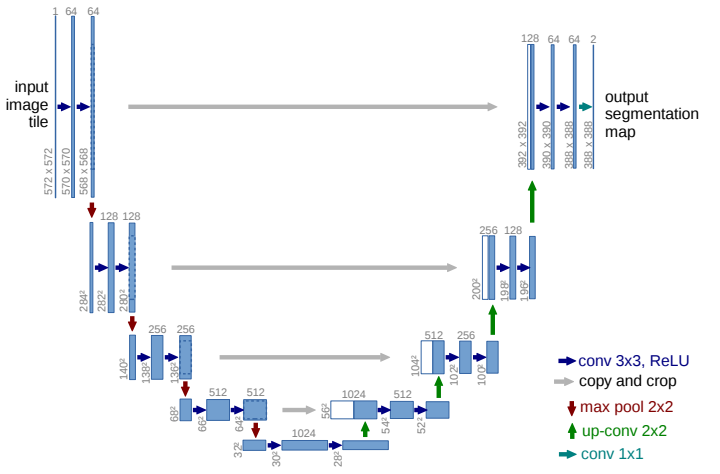

У нас в архитектуре все так же существует энкодер и декодер, как в **SegNet**, но отличительной особеностью данной модели являются *skip-conenctions*, соединяющие части декодера и энкодера. То есть для того чтобы передать на вход декодера тензор, мы конкатенируем симметричный выход с энкодера и выход предыдущего слоя декодера.

* Ronneberger, Olaf, Philipp Fischer, and Thomas Brox. "[U-Net: Convolutional networks for biomedical image segmentation.](https://arxiv.org/pdf/1505.04597.pdf)" International Conference on Medical image computing and computer-assisted intervention. Springer, Cham, 2015.

В оригинальной статье авторы не использовали padding внутри модели (это видно по тому, что размеры карты признаков уменьшаются на 2 каждый раз при движении от слоя к слою). При этом размеры входных изображений авторы единоразово увеличили при помощи mirror padding.

В этом домашнем задании вы можете применить альтернативный подход - сохранять размеры карт признаков при помощью padding = 1 во внутренних слоях.  

In [1]:
import torch.nn.functional as F
import torch.nn as nn

Для реализации UNet вы можете написать классы блоков энкодера и декодера отдельно, как мы сделали при реализации SegNet.

In [2]:
class DoubleConv(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
        )
    def forward(self, x):
        return self.conv(x)


class UNet(nn.Module):
    def __init__(self, n_class=1):
        super().__init__()
        self.inc = DoubleConv(3, 64)
        self.down1 = nn.Sequential(nn.MaxPool2d(2), DoubleConv(64, 128))
        self.down2 = nn.Sequential(nn.MaxPool2d(2), DoubleConv(128, 256))
        self.down3 = nn.Sequential(nn.MaxPool2d(2), DoubleConv(256, 512))
        self.down4 = nn.Sequential(nn.MaxPool2d(2), DoubleConv(512, 1024))

        self.up1 = nn.ConvTranspose2d(1024, 512, 2, stride=2)
        self.conv1 = DoubleConv(1024, 512)
        self.up2 = nn.ConvTranspose2d(512, 256, 2, stride=2)
        self.conv2 = DoubleConv(512, 256)
        self.up3 = nn.ConvTranspose2d(256, 128, 2, stride=2)
        self.conv3 = DoubleConv(256, 128)
        self.up4 = nn.ConvTranspose2d(128, 64, 2, stride=2)
        self.conv4 = DoubleConv(128, 64)
        self.outc = nn.Conv2d(64, n_class, 1)

    def forward(self, x):
        x1 = self.inc(x)
        x2 = self.down1(x1)
        x3 = self.down2(x2)
        x4 = self.down3(x3)
        x5 = self.down4(x4)

        x = self.up1(x5)
        x = torch.cat([x, x4], dim=1)
        x = self.conv1(x)
        x = self.up2(x)
        x = torch.cat([x, x3], dim=1)
        x = self.conv2(x)
        x = self.up3(x)
        x = torch.cat([x, x2], dim=1)
        x = self.conv3(x)
        x = self.up4(x)
        x = torch.cat([x, x1], dim=1)
        x = self.conv4(x)
        return self.outc(x)

In [15]:
unet_model = UNet().to(device)

## Обучите UNet

Задание: обучите UNet на всех трех лоссах: BCE, Dice, Focal и сравните результаты с SegNet:
*   Какая модель дает лучшие значения по метрике?
*   Какая модель дает лучшие значения по лоссам?
*   Какая модель обучается быстрее?
*   Сравните визуально результаты SegNet и UNet.

Напишите развернутый ответ на вопросы.



In [65]:
unet_model = UNet(n_class=1).to(device)
criterion = nn.BCEWithLogitsLoss()          # или ваша bce_loss с reduction='mean'
optimizer = torch.optim.Adam(unet_model.parameters(), lr=1e-4)

train(unet_model, train_dataloader, valid_dataloader, criterion, optimizer, device, num_epochs=30)

Epoch 1/30:   0%|          | 0/4 [00:00<?, ?it/s]

Epoch 1: Train Loss = 0.5921, Val Loss = 0.6771, Val IoU = 0.0000


Epoch 2/30:   0%|          | 0/4 [00:00<?, ?it/s]

Epoch 2: Train Loss = 0.4669, Val Loss = 0.6707, Val IoU = 0.0000


Epoch 3/30:   0%|          | 0/4 [00:00<?, ?it/s]

...

Epoch 28: Train Loss = 0.1686, Val Loss = 0.2356, Val IoU = 0.8185


Epoch 29/30:   0%|          | 0/4 [00:00<?, ?it/s]

Epoch 29: Train Loss = 0.1710, Val Loss = 0.2139, Val IoU = 0.8377


Epoch 30/30:   0%|          | 0/4 [00:00<?, ?it/s]

Epoch 30: Train Loss = 0.1662, Val Loss = 0.2128, Val IoU = 0.8389


In [40]:
test_loss, test_iou = test(unet_model, test_dataloader, criterion, device)
print(f"UNet Test Loss: {test_loss:.4f}, IoU: {test_iou:.4f}")

UNet Test Loss: 0.2726, IoU: 0.8478
